<a href="https://colab.research.google.com/github/Divij6/MachineLearningPractice/blob/main/LogisticRegressionForClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [38]:
def sigmoid(z):
  g = 1/(1+np.exp(-z))
  return g

In [39]:
def compute_cost_logistic(X,y,w,b):
  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    z_i = np.dot(X[i],w) + b
    f_wb_i = sigmoid(z_i)
    cost = cost + -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1 - f_wb_i)
  cost = cost/m
  return cost

In [40]:
X_train = np.array([[0.5,1.5],[1,1],[1.5,0.5],[3,0.5],[2,2],[1,2.5]])
y_train = np.array([0,0,0,1,1,1])

In [41]:
w_tmp = np.array([1,1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


In [42]:
w_array1 = np.array([1,1])
b_1 = -3
w_array2 = np.array([1,1])
b_2 = -2

print("Cost for b = -3 : ", compute_cost_logistic(X_train, y_train, w_array1, b_1))
print("Cost for b = -2 : ", compute_cost_logistic(X_train, y_train, w_array2, b_2))

Cost for b = -3 :  0.36686678640551745
Cost for b = -2 :  0.43486601811471887


In [43]:
def compute_gradient_logistic(X,y,w,b):
  m, n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0.
  for i in range(m):
    f_wb_i = sigmoid(np.dot(X[i],w) + b)
    err = f_wb_i - y[i]
    for j in range(n):
      dj_dw[j] = dj_dw[j] + err * X[i,j]
    dj_db = dj_db + err
  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db


In [44]:
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_dw_tmp, dj_db_tmp = compute_gradient_logistic(X_train, y_train, w_tmp, b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp.tolist()}" )

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


In [45]:
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):
  J_history = []
  w = copy.deepcopy(w_in)
  b = b_in
  for i in range(num_iters):
    dj_dw, dj_db = compute_gradient_logistic(X,y,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    if i < 100000:
      J_history.append(compute_cost_logistic(X,y,w,b))
    if i % math.ceil(num_iters/10) == 0:
      print(f"Iteration {i:4}: Cost {J_history[-1]}")
  return w,b,J_history

In [46]:
w_tmp  = np.zeros_like(X_train[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574
Iteration 1000: Cost 0.1590977666870457
Iteration 2000: Cost 0.08460064176930078
Iteration 3000: Cost 0.05705327279402531
Iteration 4000: Cost 0.04290759421682
Iteration 5000: Cost 0.03433847729884557
Iteration 6000: Cost 0.02860379802212006
Iteration 7000: Cost 0.02450156960879306
Iteration 8000: Cost 0.02142370332569295
Iteration 9000: Cost 0.019030137124109114

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


In [47]:
x_train = np.array([0., 1, 2, 3, 4, 5]).reshape(-1,1)
y_train = np.array([0,  0, 0, 1, 1, 1])

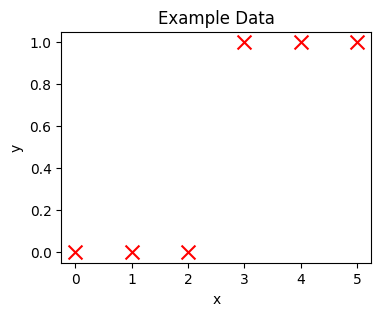

In [48]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
plt.scatter(x_train, y_train, marker='x', c='r', s=100)
plt.title("Example Data")
plt.ylabel('y')
plt.xlabel('x')
plt.show()

In [49]:
w_init = np.array([0.0])
b_init = 0.0

alpha = 0.1
iters = 10000

w_final, b_final, J_hist = gradient_descent(
    x_train,
    y_train,
    w_init,
    b_init,
    alpha,
    iters
)

print(w_final, b_final)

Iteration    0: Cost 0.6433158133057238
Iteration 1000: Cost 0.1132929921599034
Iteration 2000: Cost 0.07793458704949963
Iteration 3000: Cost 0.0611139750771269
Iteration 4000: Cost 0.05067060233609751
Iteration 5000: Cost 0.04339775780412448
Iteration 6000: Cost 0.03799053561526236
Iteration 7000: Cost 0.03379355724130196
Iteration 8000: Cost 0.030433646671395555
Iteration 9000: Cost 0.0276797908056348
[5.1198735] -12.609503113679205


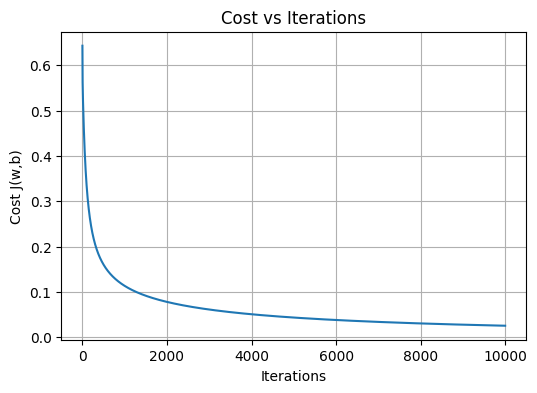

In [50]:
plt.figure(figsize=(6,4))
plt.plot(J_hist)
plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations")
plt.grid(True)
plt.show()

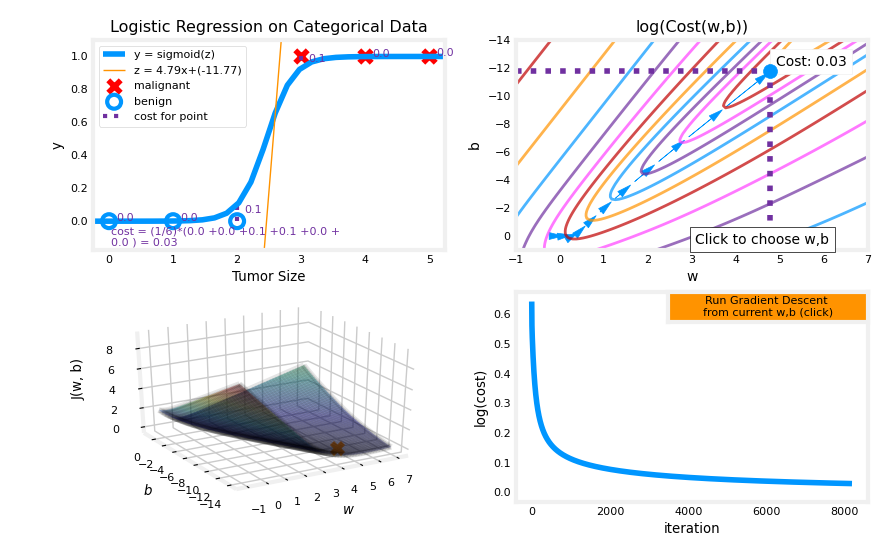

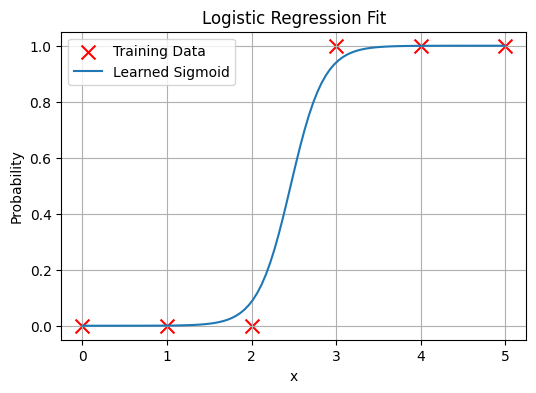

In [51]:
x_plot = np.linspace(0, 5, 100)

y_pred = sigmoid(w_final[0] * x_plot + b_final)

plt.figure(figsize=(6,4))
plt.scatter(x_train, y_train, color='red', marker='x', s=100, label='Training Data')
plt.plot(x_plot, y_pred, label='Learned Sigmoid')
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Logistic Regression Fit")
plt.legend()
plt.grid(True)
plt.show()